# 301.2. Small field areas

<div style="max-width:300px; float: left; margin-right: 1em">

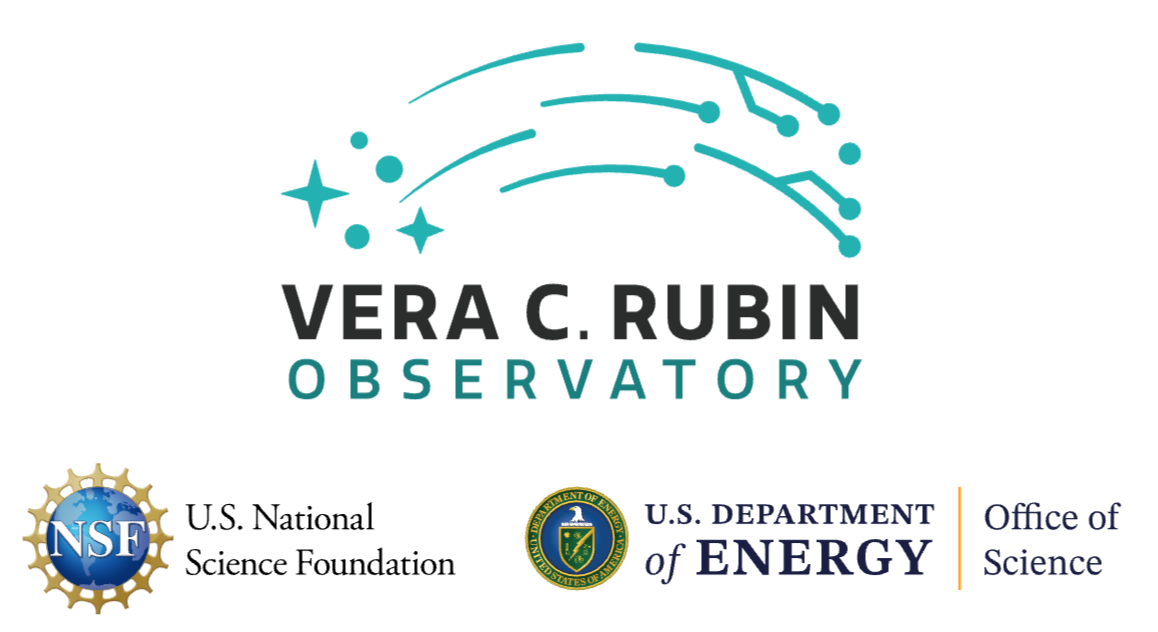

</div>

For the Rubin Science Platform at data.lsst.cloud. \
Data Release: [Data Preview 2](http://dp2.lsst.io) \
Container Size: Large \
LSST Science Pipelines version: v30.0.10 \
Last verified to run: 2026-08-11 \
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)

**Learning objective:** Learn about the small field areas in the Data Preview 2 (DP2) dataset.

**LSST data products:** `Visit` and `CoaddPatches` tables, the `skymap`, and survey property maps

**Packages:** `lsst.daf.butler`, `lsst.rsp.RSPDiscovery`

**Credit:**
Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks. 

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum. Rubin staff will respond to all questions posted there.

## 1. Introduction

This notebook provides an overview of the small field areas observed as part of the science validation survey during commissioning, and which are included in the DP2 dataset.
As shown in the 301.1. tutorial in this series, fields "Abell 2764", "DESI SV3 R1", and "Rubin SV 300 -41" had few observations ($<$100 visits) and thus are not included in this tutorial.

The figure below provides a "quicklook" at each of the 9 small field areas, showing the relative nebulosity and stellar density.

<div style="max-width:800px; float: left; margin-right: 1em">

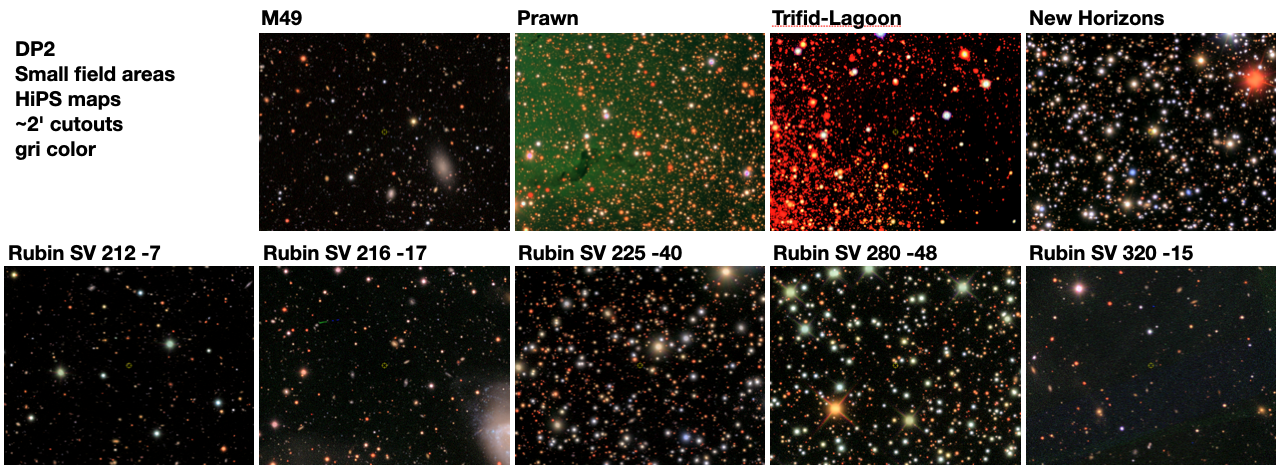

</div>

The table below contains names and coordinates (RA, Dec in decimal degrees, plus the Galactic latitude and longitude) for each of the small field areas.

<div style="float: left">
    
|Field name|RA, Dec (deg)|Gal lat, lon (deg)|R_visits (deg)|
|---|---------|---------|---------|
|M49|186.3, 6.9|68.8, 284.6|2.2|
|Prawn|253.5, -41.0|1.7, 344.1|2.7|
|Trifid-Lagoon|271.7, -23.9|-1.6, 6.7|1.9|
|New_Horizons|289.4, -20.2|-14.6, 17.4|1.5|
|Rubin_SV_212_-7|211.7, -7.0|51.3, 333.8|0.6|
|Rubin_SV_216_-17|216.1, -16.7|40.7, 332.8|0.4|
|Rubin_SV_225_-40|225.0, -39.5|16.9, 328.3|1.9|
|Rubin_SV_280_-48|280.1, -48.0|-18.1, 347.6|2.0|
|Rubin_SV_320_-15|320.2, -15.1|-39.8, 35.6|4.5|

</div>

**R_visits (deg):** The table above provides an approximate radius that encompasses the boresight (the field-of-view center) of all individual visits of the field.
It can be used as a constraint on the visit center coordinates in queries that request all visits of a particular field.
However, since the LSSCam FOV has a radius of 1.75 deg, $R_{visits}$ does not encompass every individual detector of every visit.
Similarly, as the tracts of the LSST DP2 skymap are $\sim1.66$ degrees across, $R_{visits}$ does not encompass every individual patch (deep coadd image) or detected source or object associated with that field.

**Related tutorials**: Refer to the 100-level tutorials for how to use the RSP's butler and TAP services, and the 200-level tutorials for details on the visit table, deep coadd images, and survey property maps. See also the other tutorials in the 301-series.

### 1.1. Import packages

Import `numpy` ([numpy.org](https://numpy.org)) for data array manipulation, `matplotlib` ([matplotlib.org](https://matplotlib.org/)) for plotting.
Import `astropy` ([astropy.org](https://www.astropy.org/)) and `skyproj` ([skyproj.readthedocs.io](https://skyproj.readthedocs.io/en/latest/)) for astronomy-specific functionality, and the `healpy` ([healpy.readthedocs.io](https://healpy.readthedocs.io/en/latest/)) and `hpgeom` ([hpgeom.readthedocs.io](https://hpgeom.readthedocs.io/en/latest/)) packages for dealing with HEALPix.
Also import python's "garbage collector" `gc` in order to clear memory while running the notebook.

From the `lsst` package, import modules for data access: `RSPDiscovery` and the Butler.
Use the plotting utilities in `lsst.utils.plotting` to access LSST-standard color schemes, symbols, and line styles for multi-band visualizations.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools
from astropy.table import Table, join
import astropy.units as u
from astropy.coordinates import SkyCoord
import skyproj
import healpy as hp
import hpgeom as hpg
import gc
from lsst.rsp import RSPDiscovery
from lsst.daf.butler import Butler
import lsst.afw.display as afw_display
from lsst.utils.plotting import (
    get_multiband_plot_colors,
    get_multiband_plot_symbols,
    get_multiband_plot_linestyles
)

### 1.2. Define parameters and functions

Instantiate the Butler for the DP2 dataset.

In [ ]:
butler = Butler('dp2', collections='dp2')

Instantiate the TAP service.

In [ ]:
discovery = RSPDiscovery("dp2")
tap_service = discovery.get_tap_client()

Define colors, symbols, and linestyles to represent the six LSST filters, $ugrizy$.

In [ ]:
filter_colors = get_multiband_plot_colors()
filter_names = filter_colors.keys()
filter_symbols = get_multiband_plot_symbols()
filter_linestyles = get_multiband_plot_linestyles()

Set `afwDisplay` to use `matplotlib`.

In [ ]:
afw_display.setDefaultBackend("matplotlib")

Uncomment and execute the following code cell to display plots interactively.
Revert to non-interactive plots by executing `%matplotlib inline`, or by re-commenting the line, restarting the kernel and clearing all outputs, and re-executing the notebook.

In [ ]:
# %matplotlib widget

Define a dictionary with the names and $R_{visit}$ values for the small field areas.

In [ ]:
regions = {
    "M49": [186.3, 6.9, 2.2],
    "Prawn": [253.5, -41.0, 2.7],
    "Trifid-Lagoon": [271.7, -23.9, 1.9],
    "New_Horizons": [289.4, -20.2, 1.5],
    "Rubin_SV_212_-7": [211.7, -7.0, 0.6],
    "Rubin_SV_216_-17": [216.1, -16.7, 0.4],
    "Rubin_SV_225_-40": [225.0, -39.5, 1.9],
    "Rubin_SV_280_-48": [280.1, -48.0, 2.0],
    "Rubin_SV_320_-15": [320.2, -15.1, 4.5],
}
region_names = list(regions.keys())

Define a function that will remove a figure and all its data, to help clear memory.

In [ ]:
def remove_figure(fig):
    """
    Remove a figure to reduce memory footprint.

    Parameters
    ----------
    fig: matplotlib.figure.Figure
        Figure to be removed.

    Returns
    -------
    None
    """

    for ax in fig.get_axes():
        for im in ax.get_images():
            im.remove()
    fig.clf()
    plt.close(fig)
    gc.collect()

Define a function to truncate a colormap. 
This can be used to cut off, e.g., the darkest or lightest colors, to help with data visibility.

In [ ]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    Customize a matplotlib colormap.

    Parameters
    ----------
    cmap: the matplotlib colormap
    minval: desired lower bound of colormap
    maxval: desired upper bound of colormap
    n: number of intervals (colormap resolution)

    Returns
    -------
    new_cmap: the truncated colormap
    """

    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## 2. Visits

Use the TAP service to return the visit id (`visit`), coordinates (`ra` and `dec`), filter (`band`), modified Julian date (MJD; `expMidptMJD`), and airmass of all visits included in DP2, from the `Visit` table.

In [ ]:
query = """SELECT visit, ra, dec, band, expMidptMJD, airmass FROM dp2.Visit"""
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_table = job.fetch_result().to_table()
job.delete()
del query

### 2.1. Sky map

Visualize the density of visits on an all-sky map.

Use the `healpy` package to print the area of one 19-sided HEALPix, to show that it is similar to the LSSTCam field of view (FOV) of 9.6 square degrees.

In [ ]:
print('One 19-sided HEALPix is ', np.round(hp.nside2pixarea(19, degrees=True), 2),
      ' square degrees.')
print('It takes ', int(41253.0 / hp.nside2pixarea(19, degrees=True)),
      ' 19-sided HEALPix to cover the full sky.')

Use the `skyproj` package with a McBryde skyprojection to visualize the distribution of DP2 visits on the sky in HEALPix that are approximately the same size as the LSSTCam FOV (`nside`=19).

In [ ]:
orig_cmap = plt.get_cmap('Blues')
new_cmap = truncate_colormap(orig_cmap, 0.10, 0.75)

fig, ax = plt.subplots(figsize=(12, 8))
sp = skyproj.McBrydeSkyproj(ax=ax)
vras = np.asarray(visit_table['ra'], dtype='float')
vdecs = np.asarray(visit_table['dec'], dtype='float')
sp.draw_hpxbin(vras, vdecs, nside=19, alpha=1, cmap=new_cmap)
sp.draw_colorbar(label='Number of visits (any filter)', shrink=0.5, pad=0.01)
for r, name in enumerate(region_names):
    color = 'black'
    symbol = 'o'
    sp.ax.text(regions[name][0], regions[name][1]+4, str(r+1), color=color, fontweight='bold')
    sp.ax.plot(regions[name][0], regions[name][1], symbol, ms=15, color='None', mec=color,
               label=str(r+1)+': '+name)
sp.ax.set_xlabel("Right Ascension", fontsize=14)
sp.ax.set_ylabel("Declination", fontsize=14)
sp.ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.1), ncol=5, handletextpad=0)
plt.tight_layout()
plt.show()
del sp, vras, vdecs

> **Figure 1:** A density map of the number of visits in blue, with small field survey areas marked with black circles.

Some fields are near the Galactic plane. Determine the Galactic latitude and longitude for each field and show the table.

In [ ]:
region_galactic = Table()
region_galactic['name'] = region_names
region_galactic['lat'] = np.zeros(len(region_names), dtype='float')
region_galactic['lon'] = np.zeros(len(region_names), dtype='float')
for r, name in enumerate(region_names):
    coords = regions[name]
    c = SkyCoord(ra=coords[0] * u.degree, dec=coords[1] * u.degree, frame='icrs')
    c_gal = c.galactic
    region_galactic['lon'][r] = np.round(c_gal.l.degree, 1)
    region_galactic['lat'][r] = np.round(c_gal.b.degree, 1)
region_galactic

### 2.2. Cadence

Two ways to visualize the time-domain coverage for a field are the number of observations as a function of time (the accumulate rate of data), and the pairwise time-difference histogram: the distribution of time intervals between all possible visit pairs.

For each region plot the cumulative distribution of visit dates per filter, and the pairwise time-interval distribution per filter. Store the cadence data as `cadence_data` to use below.

In [ ]:
sc_all = SkyCoord(ra = visit_table['ra'], dec = visit_table['dec'], frame='icrs')
data_start = np.floor(np.min(visit_table['expMidptMJD']))
data_end = np.ceil(np.max(visit_table['expMidptMJD']))
temp = []

fig, ax = plt.subplots(len(regions), 2, figsize=(10, 20))
for r, name in enumerate(region_names):
    ra, dec, rad = regions[name]
    sc_region = SkyCoord(ra = ra*u.deg, dec = dec*u.deg, frame='icrs')
    tx = np.where(sc_region.separation(sc_all).value <= rad)[0]
    for f, filt in enumerate(filter_names):
        fx = np.where(visit_table['band'][tx] == filt)[0]
        if len(fx) > 0:
            dates = np.sort(visit_table['expMidptMJD'][tx[fx]])
            Ncumul = np.arange(len(dates))
            ax[r, 0].plot(dates - data_start, Ncumul, ls=filter_linestyles[filt],
                          alpha=0.7, color=filter_colors[filt], label=filt)
            tdiffs = []
            for comb in itertools.combinations(dates, 2):
                tdiffs.append(comb[1] - comb[0])
            time_diffs = np.array(tdiffs)
            ax[r, 1].hist(time_diffs, bins=20, histtype='step', ls=filter_linestyles[filt],
                          alpha=0.7, color=filter_colors[filt])
            del dates, Ncumul, tdiffs, time_diffs
        del fx
    dates = np.sort(visit_table['expMidptMJD'][tx])
    tdiffs = []
    for comb in itertools.combinations(dates, 2):
        tdiffs.append(comb[1] - comb[0])
    time_diffs = np.array(tdiffs)
    temp.append((len(tx), np.mean(time_diffs)))
    del ra, dec, sc_region, tx, dates, tdiffs, time_diffs
    ax[r, 0].set_xlabel('MJD - ' + str(data_start))
    ax[r, 0].set_ylabel('Cumulative visits')
    ax[r, 0].set_xlim([0, data_end - data_start])
    ax[r, 0].set_title(name)
    ax[r, 0].legend(loc='upper right', ncol=2)
    ax[r, 1].set_xlabel('Time separation (days)')
    ax[r, 1].set_ylabel('Observation pairs')
    ax[r, 1].set_title(name)
plt.tight_layout()
plt.show()

cadence_data = np.asarray(temp)
del temp

> **Figure 2:** In the left column, plots of the cumulative number of visits over time, per filter. In the right column, the histograms of pairwise visit intervals, per filter. This figure shows which fields have more visits spread out over time, and are better for time-domain astronomy.

Plot the total number of visits vs. the average pairwise visit interval for each field. Fields that are better for time-domain astronomy will have greater values for each of these metrics.

In [ ]:
fig = plt.figure(figsize=(6, 4))
markers = ['o', 's', '*', 'X', 'd', 'v', '^', '<', 'p']
for r, name in enumerate(region_names):
    plt.plot(cadence_data[r, 0], cadence_data[r, 1], markers[r],
             ms=10, alpha=0.8, label=name)
plt.xlabel('Total number of visits')
plt.ylabel('Mean pairwise visit interval (days)')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

> **Figure 3:** The total number of visits vs. the average pairwise visit interval time, with one point representing each of the small field areas. Fields with more visits are more useful for time-domain astronomy, and fields with a longer average time interval are better for longer-duration transients and variables.

### 2.3. Image quality

The `seeing` and magnitude limit `magLim` are estimated per-detector, and are available in the `VisitDetector` table.

Use the TAP service to return the seeing and magnitude limits, averaged over all detectors per visit, from the `VisitDetector` table.

In [ ]:
query = """SELECT visitId, AVG(seeing) AS mean_seeing, AVG(magLim) AS mean_maglim
           FROM dp2.VisitDetector GROUP BY visitId"""
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
visit_detector_table = job.fetch_result().to_table()
job.delete()
del query

Combine the `mean_seeing` and `mean_maglim` columns with the `visit_table` using an `astropy` table join, to create the `joined_table`.
To save memory, delete the original tables and run the garbage collector.

In [ ]:
joined_table = join(visit_table, visit_detector_table, keys_left="visit", keys_right="visitId")
del visit_table, visit_detector_table
gc.collect()

For each region plot the distribution of visit mean seeing and mean magnitude limit, where the mean value for a visit is an average over all detectors. Store the average seeing and magnitude limits for the $i$-band as `iq_iband_data` to use below.

In [ ]:
sc_joined = SkyCoord(ra = joined_table['ra'], dec = joined_table['dec'], frame='icrs')
temp = []

fig, ax = plt.subplots(len(regions), 2, figsize=(10, 20))
for r, name in enumerate(region_names):
    ra, dec, rad = regions[name]
    # offsets = np.sqrt((joined_table['ra']-ra)**2 + (joined_table['dec']-dec)**2)
    # tx = np.where(offsets < rad)[0]
    sc_region = SkyCoord(ra = ra*u.deg, dec = dec*u.deg, frame='icrs')
    tx = np.where(sc_region.separation(sc_joined).value <= rad)[0]
    for f, filt in enumerate(filter_names):
        fx = np.where(joined_table['band'][tx] == filt)[0]
        if len(fx) > 0:
            ax[r, 0].hist(joined_table['mean_seeing'][fx], histtype='step',
                          ls=filter_linestyles[filt],
                          alpha=0.7, color=filter_colors[filt], label=filt)
            ax[r, 1].hist(joined_table['mean_maglim'][fx], histtype='step',
                          ls=filter_linestyles[filt],
                          alpha=0.7, color=filter_colors[filt], label=filt)
        if filt == 'i':
            temp.append((np.mean(joined_table['mean_seeing'][fx]),
                         np.std(joined_table['mean_seeing'][fx]),
                         np.mean(joined_table['mean_maglim'][fx]),
                         np.std(joined_table['mean_maglim'][fx])))
        del fx
    del ra, dec, sc_region, tx
    ax[r, 0].set_xlabel('Mean seeing FWHM [arcsec]')
    ax[r, 0].set_ylabel('Number of visits')
    ax[r, 0].set_title(name)
    ax[r, 0].legend(loc='upper right', ncol=2)
    ax[r, 1].set_xlabel('Mean magnitude limit [mag]')
    ax[r, 1].set_ylabel('Number of visits')
    ax[r, 1].set_title(name)
plt.tight_layout()
plt.show()
iq_iband_data = np.asarray(temp)
del temp

> **Figure 4:** Histograms of the mean visit seeing (left column) and magnitude limit (right column) by filter, for each small field area.

Plot the mean visit $i$-band seeing vs. magnitude limit, with error bars that represent the standard deviation of the seeing and magnitude limit over all visits.

In [ ]:
fig = plt.figure(figsize=(6, 4))
markers = ['o', 's', '*', 'X', 'd', 'v', '^', '<', 'p']
for r, name in enumerate(region_names):
    xval = iq_iband_data[r, 0]
    xvale = iq_iband_data[r, 1]
    yval = iq_iband_data[r, 2]
    yvale = iq_iband_data[r, 3]
    plt.errorbar(xval, yval, xerr=xvale, yerr=yvale, fmt=markers[r],
                 ms=10, alpha=0.8, label=name)
plt.xlabel('Average i-band seeing FWHM [arcsec]')
plt.ylabel('Average i-band magnitude limit [mag]')
plt.title('Image quality for i-band visits')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.show()

>**Figure 5:** For the $i$-band, the average seeing vs. the average magnitude limit for individual visits of each of the small area fields. The point of this plot that most fields have similar distributions of IQ in the $i$-band filter, which is not obvious in Figure 4 above.

Clean up.

In [ ]:
del cadence_data, iq_iband_data, joined_table
gc.collect()

## 3. Deep coadds

### 3.1. Skymap (tracts and patches)

The `skymap` of DP2 deep coadd tracts and patches was defined before all the observations were obtained.
**Just because a tract and patch exists does not mean it is populated with a deep coadd image.**
Retrieve the DP2 patch and tract numbers (`lsst_patch`, `lsst_tract`), the center coordinates RA, Dec (`s_ra`, `s_dec`), and the polygon region defining the patch (`s_region`) from the `CoaddPatches` table.

In [ ]:
query = """SELECT lsst_patch, lsst_tract, s_dec, s_ra, s_region FROM dp2.CoaddPatches"""
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
patches_table = job.fetch_result().to_table()
job.delete()
del query

Option to display the table.

In [ ]:
# patches_table

### 3.2. Survey property maps

Survey property maps consolidate information about the deep coadd images, such as the PSF (point-spread function) limiting magnitude and size (FWHM; full-width half-max).

Two commonly-used maps are:

* PSF magnitude limit, or "depth": `deepCoadd_psf_maglim_consolidated_map_weighted_mean`
* PSF size (FWHM) in pixels (0.2"/pix): `deepCoadd_psf_size_consolidated_map_weighted_mean`

Maps are available per filter.

Select the $i$-band magnitude limit map.

In [ ]:
map_name = "deepCoadd_psf_maglim_consolidated_map_weighted_mean"
map_band = "i"
map_label = "PSF " + map_name.split("_")[2] + " (" + map_band + "-band)"

### 3.3. Depth and deep coadd plots

Create a set of plots to show, side-by-side, the $i$-band depth map for the *entire* small field area, next to an example deep coadd image from the central region.

In [ ]:
for r, name in enumerate(region_names):
    coords = regions[name]
    radius = coords[2] + np.sqrt(2*1.66**2)
    delta_ra = (coords[0] - patches_table['s_ra'])*(np.cos(np.deg2rad(coords[1])))
    delta_dec = coords[1] - patches_table['s_dec']
    offset = np.sqrt(delta_ra**2 + delta_dec**2)
    tx = np.where(offset < radius)[0]
    pixels = np.unique(np.array(hpg.angle_to_pixel(32,
                                                   patches_table['s_ra'][tx],
                                                   patches_table['s_dec'][tx])))
    hspmap = butler.get(map_name, band=map_band, skymap='lsst_cells_v2',
                        parameters={'pixels': list(pixels), 'degrade_nside': 1024})

    query = "band.name = :band AND patch.region OVERLAPS POINT(:ra, :dec)"
    bind = {'band': 'i', 'ra': coords[0], 'dec': coords[1]}
    refs = butler.query_datasets("deep_coadd", where=query, bind=bind)
    deep_coadd = butler.get(refs[0])
    show_tract, show_patch = refs[0].dataId['tract'], refs[0].dataId['patch']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    sp = skyproj.Skyproj(ax=ax1)
    sp.draw_hspmap(hspmap)
    sp.draw_colorbar(label=map_label, shrink=0.8, pad=0.01)
    sp.ax.set_xlabel("Right Ascension", fontsize=14)
    sp.ax.set_ylabel("Declination", fontsize=14)
    sp.ax.tick_params(axis="x", labeltop=False)
    for x in tx:
        use_lw, use_al = 0.5, 0.5
        if patches_table['lsst_tract'][x] == show_tract:
            if patches_table['lsst_patch'][x] == show_patch:
                use_lw, use_al = 3, 1
        s_region = patches_table['s_region'][x]
        temp = s_region.split(' ')
        ras = np.asarray([temp[2], temp[4], temp[6], temp[8], temp[2]], dtype='float')
        decs = np.asarray([temp[3], temp[5], temp[7], temp[9], temp[3]], dtype='float')
        sp.ax.plot(ras, decs, color='black', alpha=use_al, linewidth=use_lw)
        del s_region, temp, ras, decs
    plt.title(name)

    plt.sca(ax2)
    display = afw_display.Display(frame=fig)
    display.scale('linear', 'zscale')
    display.image(deep_coadd.image)
    ax2.set_title('Central deep coadd patch')

    plt.tight_layout()
    plt.show()
    del coords, radius, delta_ra, delta_dec, offset
    del tx, pixels, hspmap
    del query, bind, refs, deep_coadd, show_tract, show_patch
    del sp
    gc.collect()
    remove_figure(fig)

>**Figure 6:** In the left column, visualizations of the deep coadd PSF magnitude limit in the $i$-band, with individual patches drawn as small boxes. In the right column, an example deep coadd image from the central region of the field. The exact patch for the deep coadd at right is drawn as a thick-lined box at left.

## 4. Objects

Forced photometry for all objects (detections in the deep coadd images) is stored in the `Object` table, and a variety of fluxes are measured for all objects.
Retrieve two types of magnitudes for all objects in the central region of each small field: the PSF (appropriate for point sources) and cModel (composite model; appropriate for extended objects) magnitudes.
Also retrieve the `refSizeExtendedness` column, which contains a value between 0 and 1 that indicates the likelihood of an object having an extended size.

Use a relatively small search radius of just 0.2 degrees for faster queries.

### 4.1. Extendedness

Plot the magnitude distributions for PSF and cModel magnitudes per filter, for each field, separating point sources and extended sources via the `refSizeExtendedness` parameter.

In [ ]:
minmag = 16
maxmag = 28
Nbins = (maxmag - minmag) * 4
search_radius = 0.2
temp = []

for r, name in enumerate(region_names):
    fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    region = regions[name]
    query = """SELECT u_psfMag, g_psfMag, r_psfMag, i_psfMag, z_psfMag, y_psfMag,
            u_cModelMag, g_cModelMag, r_cModelMag, i_cModelMag, z_cModelMag, y_cModelMag,
            refSizeExtendedness
            FROM dp2.Object
            WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
                  CIRCLE('ICRS', {}, {}, {})) = 1
            AND i_psfFlux_flag = 0 and i_cModel_flag = 0
            """.format(region[0], region[1], search_radius)
    job = tap_service.submit_job(query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    assert job.phase == 'COMPLETED'
    object_table = job.fetch_result().to_table()

    px = np.where(object_table['refSizeExtendedness'] < 0.5)[0]
    ex = np.where(object_table['refSizeExtendedness'] >= 0.5)[0]
    for f, filt in enumerate(filter_names):
        tpx = np.where((object_table[filt + '_psfMag'][px] > minmag) &
                       (object_table[filt + '_psfMag'][px] < maxmag))[0]
        tex = np.where((object_table[filt + '_cModelMag'][ex] > minmag) &
                       (object_table[filt + '_cModelMag'][ex] < maxmag))[0]
        if len(tpx) > 0:
            ax[0].hist(object_table[filt + '_psfMag'][px[tpx]], bins=Nbins,
                       histtype='step', ls=filter_linestyles[filt], alpha=0.7,
                       color=filter_colors[filt], label=filt)
        if len(tex) > 0:
            ax[1].hist(object_table[filt + '_cModelMag'][ex[tex]], bins=Nbins,
                       histtype='step', ls=filter_linestyles[filt], alpha=0.7,
                       color=filter_colors[filt], label=filt)
        if filt == 'i':
            ax[0].text(0.05, 0.95, '# i-band objects: ' + str(int(len(tpx))),
                       transform=ax[0].transAxes, verticalalignment='top',
                       horizontalalignment='left', fontsize=10)
            ax[1].text(0.05, 0.95, '# i-band objects: ' + str(int(len(tex))),
                       transform=ax[1].transAxes, verticalalignment='top',
                       horizontalalignment='left', fontsize=10)
            temp.append((len(tpx), len(tex)))
        del tpx, tex
    ax[0].set_xlabel('PSF magnitude')
    ax[0].set_xlim([minmag, maxmag])
    ax[1].set_xlabel('cModel magnitude')
    ax[1].set_xlim([minmag, maxmag])
    ax[0].set_title('point-like')
    ax[1].set_title('extended')
    ax[1].legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    fig.subplots_adjust(wspace=0)
    fig.suptitle(name)
    plt.show()

    del region, query
    job.delete
    del object_table, px, ex
    gc.collect()

nobj_i_data = np.asarray(temp)
del temp

> **Figure 7:** Magnitude distributions for point-like (left) and potentially-extended (right) objects, per filter, for each of the small field areas. **This is forced photometry**, so the distributions go fainter than the detection limits.

Display, for each field, the number of point-like (PL) and potentially-extended (EX) objects in the search area, and estimate the 2D sky density in number of sources per square arcminute. This is only an estimate, and not a robust measurement; the search radius was only 0.2 deg.

In [ ]:
nobj_i_table = Table()
nobj_i_table['name'] = region_names
nobj_i_table['# point-like'] = nobj_i_data[:, 0]
nobj_i_table['# extended'] = nobj_i_data[:, 1]
nobj_i_table['#PL/arcmin2'] = np.round(nobj_i_data[:, 0] / (np.pi * search_radius**2) / 60**2, 1)
nobj_i_table['#EX/arcmin2'] = np.round(nobj_i_data[:, 1] / (np.pi * search_radius**2) / 60**2, 1)
nobj_i_table

Recall that some of these fields are in the Galactic plane (are at low Galactic latitude), with high levels of extinction and crowdedness that hampers source detection and measurement (e.g., Prawn, Trifid).

In [ ]:
tx = np.where(np.abs(region_galactic['lat']) < 2)[0]
region_galactic[tx]

### 4.2. Color-magnitude and color-color diagrams

Extract `Object` catalog data with a larger radius (0.5 deg.) for a high-latitude field (Rubin_SV_212_-7) and a relatively low-latitude field (Rubin_SV_225_-40). Compare their color-magnitude and color-color diagrams.

In [ ]:
fields = ['Rubin_SV_212_-7', 'Rubin_SV_225_-40']
search_radius = 0.5
objcats = {}

for field in fields:
    region = regions[field]
    query = """SELECT g_psfMag, r_psfMag, i_psfMag,
            g_cModelMag, r_cModelMag, i_cModelMag,
            refSizeExtendedness
            FROM dp2.Object
            WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec),
                  CIRCLE('ICRS', {}, {}, {})) = 1
            AND i_psfFlux_flag = 0 and i_cModel_flag = 0
            """.format(region[0], region[1], search_radius)
    job = tap_service.submit_job(query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    assert job.phase == 'COMPLETED'
    object_table = job.fetch_result().to_table()
    objcats[field] = object_table

Set the `refSizeExtendedness` threshold to 0.25, to select a more pure sample of point sources.

In [ ]:
cat_sv212_m7 = objcats['Rubin_SV_212_-7']
cat_sv225_m40 = objcats['Rubin_SV_225_-40']

ptsource_sv212_m7 = np.where(cat_sv212_m7['refSizeExtendedness'] < 0.25)[0]
extsource_sv212_m7 = np.where(cat_sv212_m7['refSizeExtendedness'] >= 0.25)[0]
ptsource_sv225_m40 = np.where(cat_sv225_m40['refSizeExtendedness'] < 0.25)[0]
extsource_sv225_m40 = np.where(cat_sv225_m40['refSizeExtendedness'] >= 0.25)[0]

Plot the color-magnitude ($r$ vs. $g-r$) and color-color ($r-i$ vs. $g-r$) diagrams for each field, separating point and extended sources.

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 6),
                                             height_ratios=[1, 2.5])
plt.subplots_adjust(hspace=0, wspace=0)

grmin, grmax = -0.9, 2.3
rimin, rimax = -1.3, 2.8
magmin, magmax = 15.8, 26.8

ax1.hexbin(cat_sv212_m7[ptsource_sv212_m7]['g_psfMag']-cat_sv212_m7[ptsource_sv212_m7]['r_psfMag'],
           cat_sv212_m7[ptsource_sv212_m7]['r_psfMag']-cat_sv212_m7[ptsource_sv212_m7]['i_psfMag'],
           gridsize=(150, 150),
           extent=(grmin, grmax, rimin, rimax), bins='log', cmap='Grays')
ax1.set_title('Point sources (PSF mags)')
ax1.set_xlim(grmin, grmax)
ax1.set_ylim(rimin, rimax)
ax1.set_ylabel(r'(r−i)')
ax1.set_xticklabels([])
ax1.minorticks_on()

ax2.hexbin(cat_sv212_m7[extsource_sv212_m7]['g_cModelMag']-cat_sv212_m7[extsource_sv212_m7]['r_cModelMag'],
           cat_sv212_m7[extsource_sv212_m7]['r_cModelMag']-cat_sv212_m7[extsource_sv212_m7]['i_cModelMag'],
           gridsize=(150, 150),
           extent=(grmin, grmax, rimin, rimax), bins='log', cmap='Grays')
ax2.set_title('Extended sources (cModel mags)')
ax2.set_xlim(grmin, grmax)
ax2.set_ylim(rimin, rimax)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.minorticks_on()

ax3.hexbin(cat_sv212_m7[ptsource_sv212_m7]['g_psfMag']-cat_sv212_m7[ptsource_sv212_m7]['r_psfMag'],
           cat_sv212_m7[ptsource_sv212_m7]['r_psfMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax3.set_xlim(grmin, grmax)
ax3.set_ylim(magmax, magmin)
ax3.set_xlabel(r'(g−r)')
ax3.set_ylabel(r'r magnitude')
ax3.minorticks_on()

ax4.hexbin(cat_sv212_m7[extsource_sv212_m7]['g_cModelMag']-cat_sv212_m7[extsource_sv212_m7]['r_cModelMag'],
           cat_sv212_m7[extsource_sv212_m7]['r_cModelMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax4.set_xlim(grmin, grmax)
ax4.set_ylim(magmax, magmin)
ax4.set_xlabel(r'(g−r)')
ax4.set_yticklabels([])
ax4.minorticks_on()

plt.suptitle('Rubin_SV_212_-7; Galactic latitude: 51.3 deg.')
plt.show()

> **Figure 8:** Color-magnitude (CMD; $r$ vs. $g-r$) and color-color ($r-i$ vs. $g-r$) diagrams for the SV_212_-7 field. The left column shows likely stars (`refSizeExtendedness` < 0.25) using `PSF` magnitudes, and the right column shows likely galaxies using `cModel` magnitudes. Top panels display color-color diagrams, and the bottom panels show the CMDs. This high-latitude field has few features in the stellar diagrams, as it is mainly populated by galaxies.

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 6),
                                             height_ratios=[1, 2.5])
plt.subplots_adjust(hspace=0, wspace=0)

grmin, grmax = -0.9, 2.3
rimin, rimax = -1.3, 2.8
magmin, magmax = 15.8, 26.8

ax1.hexbin(cat_sv225_m40[ptsource_sv225_m40]['g_psfMag']-cat_sv225_m40[ptsource_sv225_m40]['r_psfMag'],
           cat_sv225_m40[ptsource_sv225_m40]['r_psfMag']-cat_sv225_m40[ptsource_sv225_m40]['i_psfMag'],
           gridsize=(150, 150),
           extent=(grmin, grmax, rimin, rimax), bins='log', cmap='Grays')
ax1.set_title('Point sources (PSF mags)')
ax1.set_xlim(grmin, grmax)
ax1.set_ylim(rimin, rimax)
ax1.set_ylabel(r'(r−i)')
ax1.set_xticklabels([])
ax1.minorticks_on()

ax2.hexbin(cat_sv225_m40[extsource_sv225_m40]['g_cModelMag']-cat_sv225_m40[extsource_sv225_m40]['r_cModelMag'],
           cat_sv225_m40[extsource_sv225_m40]['r_cModelMag']-cat_sv225_m40[extsource_sv225_m40]['i_cModelMag'],
           gridsize=(150, 150),
           extent=(grmin, grmax, rimin, rimax), bins='log', cmap='Grays')
ax2.set_title('Extended sources (cModel mags)')
ax2.set_xlim(grmin, grmax)
ax2.set_ylim(rimin, rimax)
ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.minorticks_on()

ax3.hexbin(cat_sv225_m40[ptsource_sv225_m40]['g_psfMag']-cat_sv225_m40[ptsource_sv225_m40]['r_psfMag'],
           cat_sv225_m40[ptsource_sv225_m40]['r_psfMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax3.set_xlim(grmin, grmax)
ax3.set_ylim(magmax, magmin)
ax3.set_xlabel(r'(g−r)')
ax3.set_ylabel(r'r magnitude')
ax3.minorticks_on()

ax4.hexbin(cat_sv225_m40[extsource_sv225_m40]['g_cModelMag']-cat_sv225_m40[extsource_sv225_m40]['r_cModelMag'],
           cat_sv225_m40[extsource_sv225_m40]['r_cModelMag'], gridsize=(150, 200),
           extent=(grmin, grmax, magmin, magmax), bins='log', cmap='Grays')
ax4.set_xlim(grmin, grmax)
ax4.set_ylim(magmax, magmin)
ax4.set_xlabel(r'(g−r)')
ax4.set_yticklabels([])
ax4.minorticks_on()

plt.suptitle('Rubin_SV_225_-40; Galactic latitude: 16.9 deg.')
plt.show()

> **Figure 9:** Color-magnitude (CMD; $r$ vs. $g-r$) and color-color ($r-i$ vs. $g-r$) diagrams for the SV_225_-40 field. The left column shows likely stars (`refSizeExtendedness` < 0.25) using `PSF` magnitudes, and the right column shows likely galaxies using `cModel` magnitudes. Top panels display color-color diagrams, and the bottom panels show the CMDs. This low-latitude field has a clearly defined stellar locus in the color-color diagram.

As expected, the lower latitude field has many more Milky Way stars and a very clearly defined stellar locus in the point-source color-color diagram. Some Milky Way stars are evident in the high-latitude field, but the majority of objects are galaxies.